# Compare our output to the Thrasher implementation

This notebook compares downscaled data when running our approach trained on (1) ERA5 and (2) PGMF. We then take (2) and are able to compare it to the NEX-GDDP dataset which was trained on the same dataset. These two should be ~similar since we are largely just porting over the implementation into Python from NCL, and have implemented it largely the same.

First we do a baseline comparison between our implementation using the two different training datasets.

In [1]:
import math

import boto3
import icechunk
import matplotlib.pyplot as plt
import xarray as xr

from srm import catalog

In [2]:
def open_icechunk(path):
    bucket, prefix = path.replace("s3://", "").split("/", 1)
    storage = icechunk.s3_storage(bucket=bucket, prefix=prefix)
    repo = icechunk.Repository.open(storage)
    session = repo.readonly_session("main")

    ds = xr.open_dataset(session.store, engine="zarr", chunks={})
    return ds

In [3]:
def get_fname(var, scenario, version="test015_benchmark", ens="007", training_dataset="era5"):
    fname = (
        "s3://carbonplan-srm/output/qa/"
        + version
        + "/"
        + scenario
        + "/CESM2-WACCM/"
        + var
        + "/"
        + ens
        + "/lat-35.0to-22.0_lon16.0to33.0/"
        + training_dataset
        + "/*/"
        + scenario
        + ".icechunk/"
    )

    return fname

In [4]:
def resolve_s3_glob(path):
    """Resolve a single * wildcard in an S3 path to a real path."""
    bucket, prefix = path.replace("s3://", "").split("/", 1)

    before, after = prefix.split("*/", 1)

    s3 = boto3.client("s3")
    response = s3.list_objects_v2(Bucket=bucket, Prefix=before, Delimiter="/")

    matches = [f"s3://{bucket}/{cp['Prefix']}{after}" for cp in response.get("CommonPrefixes", [])]

    if not matches:
        raise ValueError(f"No S3 paths matched: {path}")
    if len(matches) > 1:
        raise ValueError(f"Multiple matches: {matches}")

    return matches[0]

In [5]:
def plot_comparison(da1, da2, subtitle1='', subtitle2='', suptitle=''):
    diff = da1 - da2
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    da1.plot(ax=axes[0], cmap='viridis')
    axes[0].set_title(subtitle1)
    da2.plot(ax=axes[1], cmap='viridis')
    axes[1].set_title(subtitle2)
    diff.plot(ax=axes[2], cmap='RdBu_r')
    axes[2].set_title(f'difference ({subtitle1} - {subtitle2})')
    fig.suptitle(suptitle)
    plt.tight_layout()

We'll keep the comparison to `tas` and `ssp245` for now. First read in the dataset we made training to PGMF.

In [41]:
var="tas"
scenario="ssp245"
version="obs_comparison"
ens="003"
fname = get_fname(var=var, scenario=scenario, version=version, ens=ens, training_dataset="gdex-gmf-icechunk")
fname = resolve_s3_glob(fname)
cp_pgmf = open_icechunk(path=fname)[var]
coarse = catalog.get("CESM2-WACCM-SSP245-icechunk").to_xarray()['tas'].sel(ensemble_member="003")

Then we do the apples-to-apples comparison between nex-gddp and our PGMF implementation.

In [7]:
# read in the nex-gddp dataset (Thrasher et al (2022)'s implementation, trained on PGMF)

In [19]:
nex = catalog.get("NASA-NEX-SSP245").to_xarray()
nex['time'] = nex.indexes['time'].to_datetimeindex()
# subset to the area that this test area covers
nex = nex.sel(lat=cp_pgmf.lat, lon=cp_pgmf.lon, time=slice('2015', '2099'))[var].load()

/tmp/ipykernel_196303/1992045871.py:2: FutureWarning: In a future version of xarray to_datetimeindex will default to returning a 'us'-resolution DatetimeIndex instead of a 'ns'-resolution DatetimeIndex. This warning can be silenced by explicitly passing the `time_unit` keyword argument.
  nex['time'] = nex.indexes['time'].to_datetimeindex()
/tmp/ipykernel_196303/1992045871.py:2: RuntimeWarning: Converting a CFTimeIndex with dates from a non-standard calendar, 'noleap', to a pandas.DatetimeIndex, which uses dates from the standard calendar.  This may lead to subtle errors in operations that depend on the length of time between dates.
  nex['time'] = nex.indexes['time'].to_datetimeindex()


In [20]:
cp_pgmf = cp_pgmf.sel(time=slice('2015', '2099')).load() # our dataset includes 2100 but nex does not so subset to same time range

In [10]:
# compare a pi day for of nex-gddp and our PGMF implementation

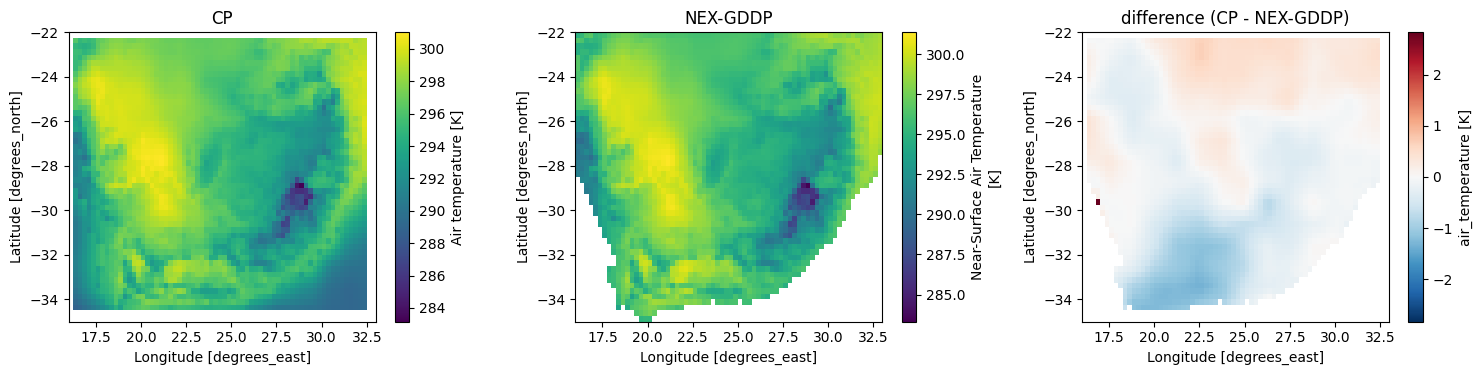

In [51]:
single_day = '2015-03-14'
plot_comparison(cp_pgmf.sel(time=single_day).load(), nex.sel(time=single_day).load(),  subtitle1='CP', subtitle2='NEX-GDDP')

In [ ]:
# compare mean tas

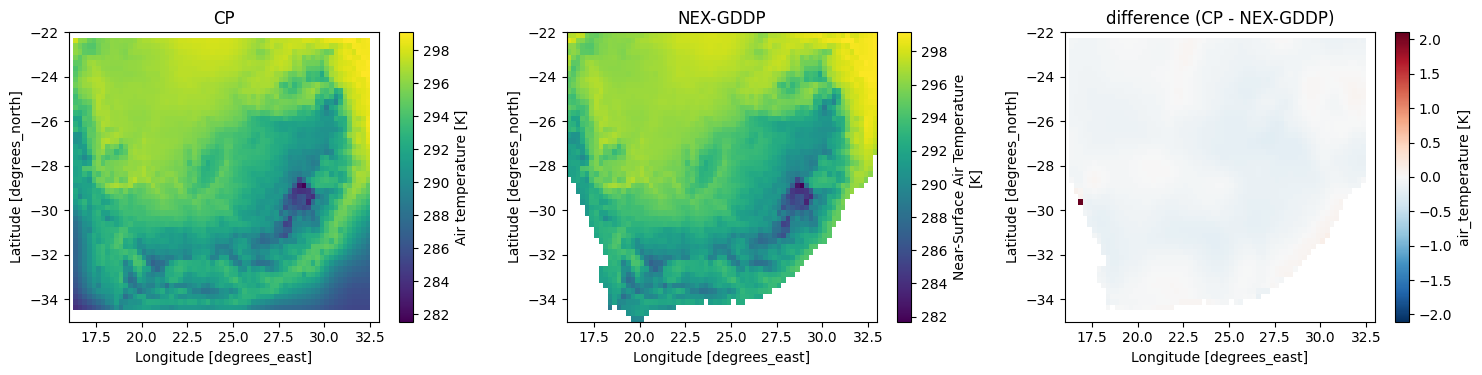

In [52]:
plot_comparison(cp_pgmf.mean(dim='time'), nex.mean(dim='time'),  subtitle1='CP', subtitle2='NEX-GDDP')

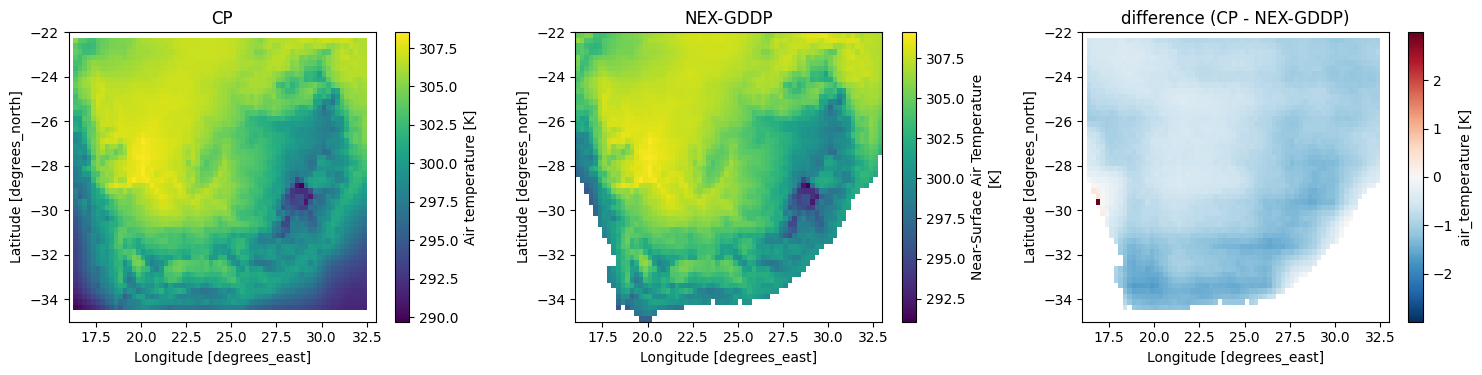

In [54]:
# compare 99p tas
plot_comparison(cp_pgmf.quantile(q=0.99, dim='time').load(), 
                nex.quantile(q=0.99, dim='time').load(),  
                subtitle1='CP', 
                subtitle2='NEX-GDDP')

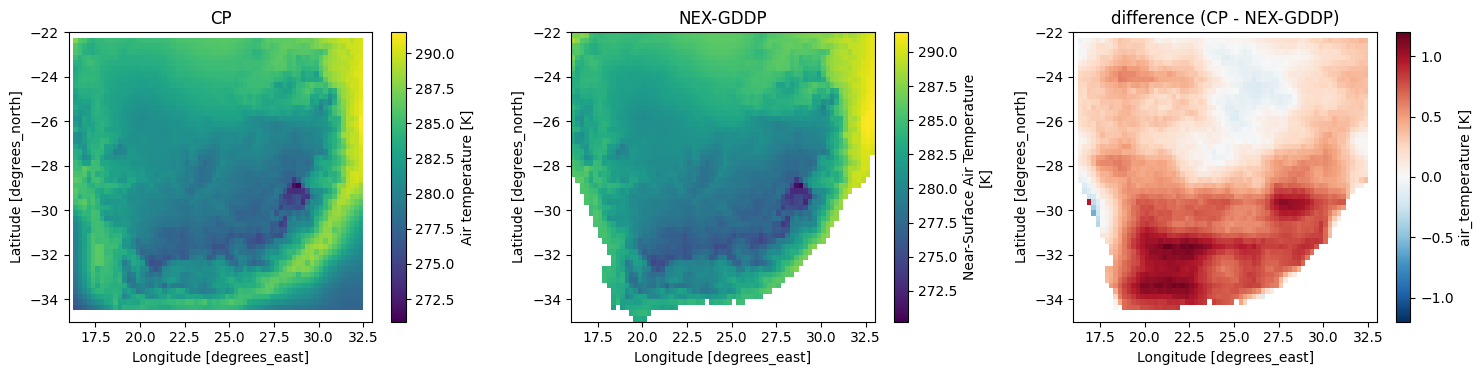

In [56]:
# compare 01p tas
plot_comparison(cp_pgmf.quantile(q=0.01, dim='time').load(), 
                nex.quantile(q=0.01, dim='time').load(),  
                subtitle1='CP', 
                subtitle2='NEX-GDDP')

Look at individual timeseries of a year of actual data to confirm same ensemble member and look for patterns of deviations.

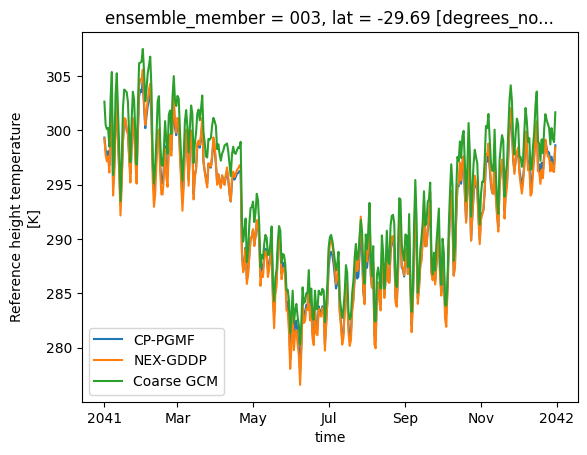

In [44]:
lat=-30.125
lon=20.125
cp_pgmf.sel(lat=lat, lon=lon, time=slice('2041', '2041')).plot(label='CP-PGMF')
nex.sel(lat=lat, lon=lon, time=slice('2041', '2041')).plot(label='NEX-GDDP')
coarse.sel(lat=lat, lon=lon, method='nearest').sel(time=slice('2041', '2041')).plot(label='Coarse GCM')
plt.legend()

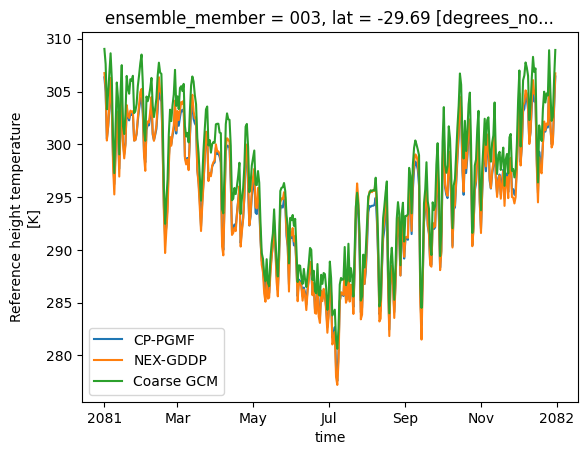

In [45]:
lat=-30.125
lon=20.125
cp_pgmf.sel(lat=lat, lon=lon, time=slice('2081', '2081')).plot(label='CP-PGMF')
nex.sel(lat=lat, lon=lon, time=slice('2081', '2081')).plot(label='NEX-GDDP')
coarse.sel(lat=lat, lon=lon, method='nearest').sel(time=slice('2081', '2081')).plot(label='Coarse GCM')

plt.legend()

Let's inspect the days when our approach is markedly cooler than NEX ~August 5 2081.

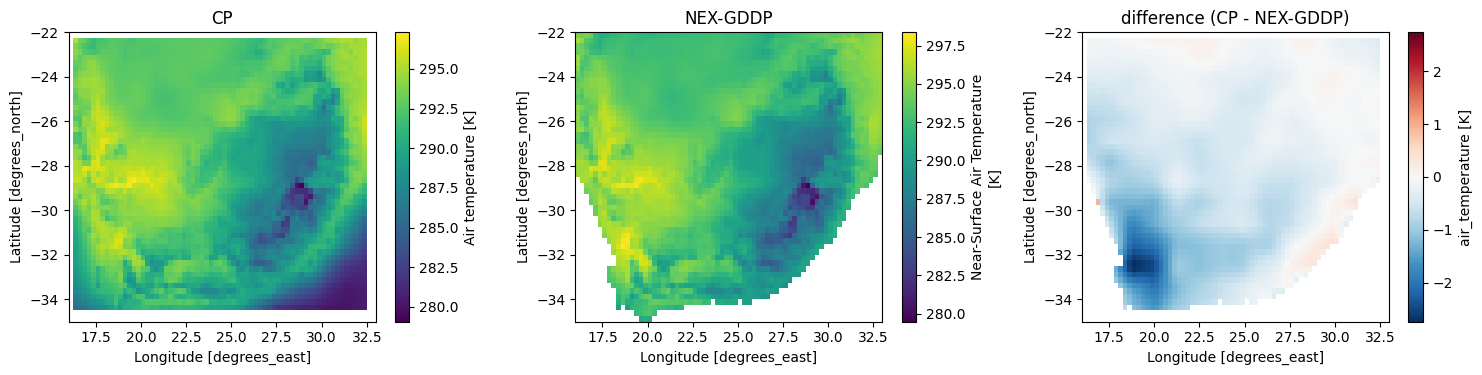

In [35]:
single_day = '2081-08-05'
plot_comparison(cp_pgmf.sel(time=single_day).load(), nex.sel(time=single_day).load(),  subtitle1='CP', subtitle2='NEX-GDDP')

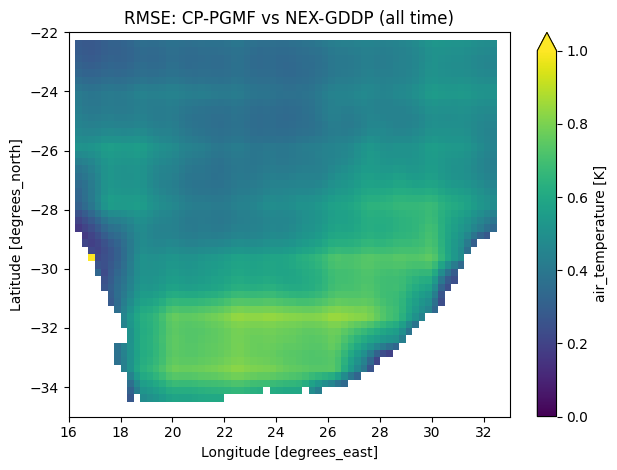

In [34]:
import numpy as np

nex_sq = nex.squeeze('ensemble_member')
rmse = np.sqrt(((cp_pgmf - nex_sq) ** 2).mean(dim='time')).load()

fig, ax = plt.subplots()
rmse.plot(ax=ax, vmax=1, vmin=0)
ax.set_title('RMSE: CP-PGMF vs NEX-GDDP (all time)')
plt.tight_layout()